<a href="https://colab.research.google.com/github/thaisun95/Unsupervised_deep_learning/blob/main/02_mnist_pca_complet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST — PCA *from scratch* : préparation, tests et démonstrations

Notebook complet pour la partie **PCA** de la lib (numpy + matplotlib uniquement).

Il est organisé en deux temps :

1. **Vérification de correction** — des `assert` qui prouvent que l'algèbre est juste
   (orthonormalité, `var(Zⱼ) = λⱼ`, identité de reconstruction). Ces tests tournent sur le
   **train** : ce sont des tests unitaires du code, pas des mesures de modèle.
2. **Démonstrations** — visualisations claires de ce que la PCA fait, en faisant varier son
   **seul** paramètre `k` (nombre de composantes). Elles tournent sur le **test** :
   des images jamais vues à l'entraînement.

La dernière section sort du cadre de la PCA pour comparer des **fonctions d'activation** —
qui n'existent **que** dans l'auto-encodeur — avec la PCA comme ligne de base linéaire.

## 1. Récupération et préparation des données

In [ ]:
import gzip
from pathlib import Path
from urllib.request import Request, urlopen

import numpy as np

DATA_DIR = Path("./data/mnist")
MIRRORS = [
    "https://ossci-datasets.s3.amazonaws.com/mnist/",
    "https://storage.googleapis.com/cvdf-datasets/mnist/",
]
FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}


def fetch(fname):
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    dest = DATA_DIR / fname
    if dest.exists():
        return dest
    for base in MIRRORS:
        try:
            req = Request(base + fname, headers={"User-Agent": "Mozilla/5.0"})
            with urlopen(req, timeout=60) as r:
                blob = r.read()
            dest.write_bytes(blob)
            return dest
        except Exception:
            continue
    raise RuntimeError(f"téléchargement impossible : {fname}")


def read_idx(path):
    with gzip.open(path, "rb") as f:
        blob = f.read()
    magic = int.from_bytes(blob[:4], "big")
    ndim = magic & 0xFF
    shape = tuple(int.from_bytes(blob[4 + 4 * i : 8 + 4 * i], "big") for i in range(ndim))
    return np.frombuffer(blob, dtype=np.uint8, offset=4 + 4 * ndim).reshape(shape).copy()


def balanced_subset(y, n_per_class):
    parts = []
    for c in range(10):
        idx_c = np.flatnonzero(y == c)
        if len(idx_c) < n_per_class:
            raise ValueError(f"classe {c} : {len(idx_c)} exemples < {n_per_class}")
        parts.append(idx_c[:n_per_class])
    return np.sort(np.concatenate(parts))


N_PER_CLASS_TRAIN, N_PER_CLASS_TEST = 1000, 200

img_train_all = read_idx(fetch(FILES["train_images"]))
y_train_all = read_idx(fetch(FILES["train_labels"]))
img_test_all = read_idx(fetch(FILES["test_images"]))
y_test_all = read_idx(fetch(FILES["test_labels"]))

i_train = balanced_subset(y_train_all, N_PER_CLASS_TRAIN)
i_test = balanced_subset(y_test_all, N_PER_CLASS_TEST)

img_train, y_train = img_train_all[i_train], y_train_all[i_train]
img_test, y_test = img_test_all[i_test], y_test_all[i_test]

X_train = img_train.reshape(len(img_train), -1).astype(np.float32) / 255.0
X_test = img_test.reshape(len(img_test), -1).astype(np.float32) / 255.0

print("X_train", X_train.shape, X_train.dtype, "min/max", X_train.min(), X_train.max())
print("X_test ", X_test.shape)
print("classes train", np.bincount(y_train))

X_train (10000, 784) float32 min/max 0.0 1.0
X_test  (2000, 784)
classes train [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


Contrôle visuel de l'alignement images / labels :

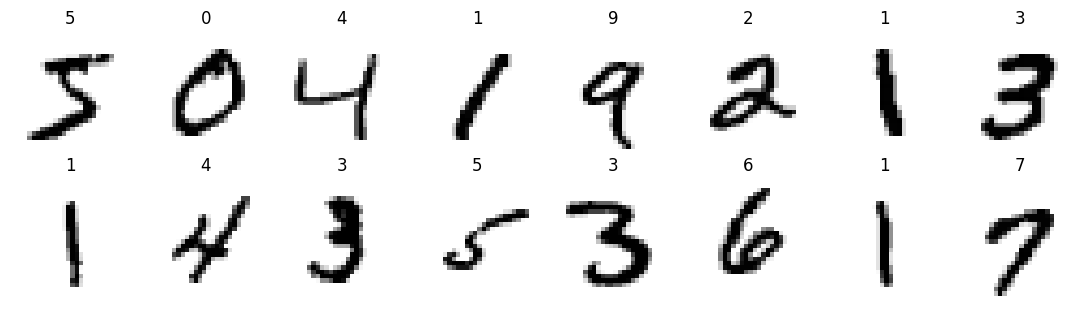

NameError: name 'class_names' is not defined

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(11, 3.2))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(int(y_train[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()

assert len(X_train) == len(y_train) and len(X_test) == len(y_test)
#assert set(np.unique(y_train)) == set(range(10))
assert set(np.unique(y_train)) == set(range(10))
print("alignement OK")

POUMONS :

In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image

# ============ PARAMÈTRES ============
IMG_SIDE = 64
N_PER_CLASS_TRAIN = 600
N_PER_CLASS_TEST = 100
SEED = 0
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp"}

BASE = Path("/root/.cache/kagglehub/datasets/nashidulopul/chest-x-ray-dataset/versions/1/Chest_Radiography_Database")


def load_chest_xray(base, side=IMG_SIDE,
                    n_train=N_PER_CLASS_TRAIN, n_test=N_PER_CLASS_TEST, seed=SEED):
    base = Path(base)
    class_names = sorted(d.name for d in base.iterdir() if d.is_dir())
    rng = np.random.default_rng(seed)

    Xtr, ytr, Xte, yte = [], [], [], []
    for label, cname in enumerate(class_names):
        files = sorted(p for p in (base / cname).iterdir() if p.suffix.lower() in IMG_EXT)
        need = n_train + n_test
        if len(files) < need:
            raise ValueError(f"{cname} : {len(files)} images < {need} demandées "
                             f"(baisse N_PER_CLASS_TRAIN/TEST)")
        idx = rng.permutation(len(files))
        tr_idx, te_idx = idx[:n_train], idx[n_train:n_train + n_test]

        for split_idx, Xl, yl in [(tr_idx, Xtr, ytr), (te_idx, Xte, yte)]:
            for i in split_idx:
                img = Image.open(files[i]).convert("L").resize((side, side))
                Xl.append(np.asarray(img, dtype=np.float32).ravel())
                yl.append(label)

    def finalize(X, y):
        X = np.stack(X) / 255.0
        y = np.array(y, dtype=np.uint8)
        o = rng.permutation(len(y))
        return X[o], y[o]

    X_train, y_train = finalize(Xtr, ytr)
    X_test, y_test = finalize(Xte, yte)
    return X_train, y_train, X_test, y_test, class_names


X_train, y_train, X_test, y_test, class_names = load_chest_xray(BASE)

print("classes :", {i: c for i, c in enumerate(class_names)})
print("X_train", X_train.shape, X_train.dtype, "min/max", X_train.min(), X_train.max())
print("X_test ", X_test.shape)
print("équilibre train :", np.bincount(y_train), "| test :", np.bincount(y_test))

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/nashidulopul/chest-x-ray-dataset/versions/1/Chest_Radiography_Database'

## 2. La classe PCA

Le **centrage vit à l'intérieur** de la classe (`mean_` est un paramètre appris sur le train,
au même titre que `components_`), pas dans la préparation. `reconstruct(X, k)` compresse sur
les `k` premières composantes puis décompresse en ré-ajoutant la moyenne.

In [ ]:
class PCA:
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        n, d = X.shape
        k = d if self.n_components is None else min(self.n_components, d)

        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        cov = (Xc.T @ Xc) / (n - 1)

        eigvals, eigvecs = np.linalg.eigh(cov)
        order = np.argsort(eigvals)[::-1]
        eigvals = np.maximum(eigvals[order], 0.0)
        eigvecs = eigvecs[:, order]

        for i in range(eigvecs.shape[1]):
            j = np.argmax(np.abs(eigvecs[:, i]))
            if eigvecs[j, i] < 0:
                eigvecs[:, i] *= -1.0

        self.total_variance_ = float(eigvals.sum())
        self.all_variances_ = eigvals
        self.components_ = eigvecs[:, :k].T
        self.explained_variance_ = eigvals[:k]
        self.explained_variance_ratio_ = eigvals[:k] / self.total_variance_
        self.n_components_ = k
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, Z):
        return np.asarray(Z, dtype=np.float64) @ self.components_ + self.mean_

    def reconstruct(self, X, n_components=None):
        Z = self.transform(X)
        if n_components is not None:
            Z = Z[:, :n_components]
            return Z @ self.components_[:n_components] + self.mean_
        return self.inverse_transform(Z)

On ajuste la PCA **une seule fois** ; toutes les cellules suivantes réutilisent cet objet.

In [ ]:
pca = PCA().fit(X_train)
print("composantes calculées :", pca.n_components_)

## 3. Tests de correction (sur le TRAIN)

Ces `assert` répondent à **« mon code est-il juste ? »**. Ils tournent sur le train parce que
`λⱼ` et `mean_` y sont *définis* : les lancer sur le test échouerait sans qu'aucun bug n'existe.

Le test le plus fort est l'**identité de reconstruction** : l'erreur avec `k` composantes vaut
*exactement* la somme des valeurs propres jetées, `(n-1)/n · Σ λⱼ pour j>k`. Ce n'est pas une
approximation : si elle passe, décomposition, tri, projection et reconstruction sont tous corrects.

In [ ]:
K = 200
G = pca.components_[:K] @ pca.components_[:K].T
err_ortho = np.abs(G - np.eye(K)).max()
print(f"orthonormalité   ||CCᵀ - I||max = {err_ortho:.2e}")
assert err_ortho < 1e-9

Z_tr = pca.transform(X_train)
err_var = np.abs(Z_tr.var(axis=0, ddof=1) - pca.explained_variance_).max()
err_mean = np.abs(Z_tr.mean(axis=0)).max()
print(f"var(Zⱼ) vs λⱼ           écart max = {err_var:.2e}")
print(f"moyenne de Z (train)              = {err_mean:.2e}")
assert err_var < 1e-8

n = len(X_train)
print(f"\n{'k':>5} {'MSE mesurée':>14} {'théorique':>14} {'écart':>10}")
for k in [2, 10, 50, 100, 200]:
    mse = float(((X_train - pca.reconstruct(X_train, k)) ** 2).sum(axis=1).mean())
    theo = (n - 1) / n * pca.all_variances_[k:].sum()
    print(f"{k:5d} {mse:14.4f} {theo:14.4f} {abs(mse-theo):10.2e}")
    assert abs(mse - theo) < 1e-6 * max(1.0, theo)
print("\ntous les tests de correction passent")

## 4. Combien de composantes ? (éboulis + variance cumulée)

784 dimensions, mais la variance est concentrée sur les premières : ~86 suffisent pour 90 %.

In [ ]:
from matplotlib import pyplot as plt

ratio = pca.explained_variance_ratio_
cum = np.cumsum(ratio)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].bar(range(1, 31), ratio[:30] * 100, color="#3b6ea5")
ax[0].set_xlabel("composante"); ax[0].set_ylabel("% de variance")
ax[0].set_title("Éboulis — 30 premières"); ax[0].grid(alpha=0.3, axis="y")

ax[1].plot(range(1, len(cum) + 1), cum * 100, color="#3b6ea5")
for t, col in [(0.90, "#c26b3e"), (0.95, "#4a7c59")]:
    k = int(np.searchsorted(cum, t) + 1)
    ax[1].axhline(t * 100, ls="--", lw=1, color=col)
    ax[1].axvline(k, ls="--", lw=1, color=col)
    ax[1].annotate(f"{t:.0%} → {k} comp.", (k, t * 100), xytext=(k + 30, t * 100 - 9),
                   color=col, fontsize=10)
ax[1].set_xlabel("nombre de composantes"); ax[1].set_ylabel("% cumulé")
ax[1].set_title("Variance expliquée cumulée"); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

for t in [0.50, 0.80, 0.90, 0.95, 0.99]:
    print(f"{t:.0%} de variance -> {int(np.searchsorted(cum, t) + 1):3d} composantes")

## 5. Les composantes principales (« eigendigits »)

Rouge = poids positif, bleu = négatif. Ce ne sont **pas** des chiffres mais des directions de
contraste. PC1 oppose typiquement les grandes boucles (0) aux traits verticaux (1).

In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(12, 4))
axes[0, 0].imshow(pca.mean_.reshape(IMG_SIDE, IMG_SIDE), cmap="gray_r")
axes[0, 0].set_title("moyenne", fontsize=9); axes[0, 0].axis("off")
for m, ax in enumerate(axes.ravel()[1:]):
    ax.imshow(pca.components_[m].reshape(IMG_SIDE, IMG_SIDE), cmap="RdBu_r")
    ax.set_title(f"PC{m+1}  ({ratio[m]*100:.1f} %)", fontsize=9); ax.axis("off")
fig.suptitle("Moyenne et 13 premières composantes principales")
plt.tight_layout()
plt.show()

## 6. Espace latent 2D (train vs test)

In [ ]:
Z_train = pca.transform(X_train)[:, :2]
Z_test = pca.transform(X_test)[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), constrained_layout=True, sharex=True, sharey=True)
cmap = plt.get_cmap("tab10", 10)
for ax, Z, yy, ttl in [(axes[0], Z_train, y_train, "TRAIN"),
                       (axes[1], Z_test, y_test, "TEST")]:
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=yy, cmap=cmap, s=4, alpha=0.4, linewidths=0)
    ax.set_title(f"Espace latent PCA — {ttl}")
    ax.set_xlabel(f"PC1 ({ratio[0]*100:.1f} %)")
    ax.set_ylabel(f"PC2 ({ratio[1]*100:.1f} %)")
    ax.grid(alpha=0.25)
fig.colorbar(sc, ax=axes.ravel().tolist(), ticks=range(10), label="chiffre réel")
plt.show()

## 7. Performance (sur le TEST)

Ici on répond à **« le modèle vaut-il quelque chose ? »**, donc sur des images jamais vues.
La courbe montre l'écart train/test (généralisation) ; le tableau donne les chiffres à rapporter.

In [ ]:
ks = np.arange(1, 201)
train_loss, test_loss = [], []
for k in ks:
    train_loss.append(((X_train - pca.reconstruct(X_train, k)) ** 2).mean())
    test_loss.append(((X_test - pca.reconstruct(X_test, k)) ** 2).mean())

plt.figure(figsize=(8, 5))
plt.plot(ks, train_loss, label="train")
plt.plot(ks, test_loss, label="test")
plt.xlabel("nombre de composantes"); plt.ylabel("MSE de reconstruction (par pixel)")
plt.title("Erreur de reconstruction PCA — train vs test")
plt.legend(); plt.grid(True)
plt.show()

In [ ]:
var_test = ((X_test - pca.mean_) ** 2).sum(axis=1).mean()
Z_te = pca.transform(X_test)
print(f"{'k':>5} {'MSE test':>11} {'variance retenue':>18}")
for k in [2, 10, 50, 86, 100, 200]:
    mse = float(((X_test - pca.reconstruct(X_test, k)) ** 2).sum(axis=1).mean())
    cap = (Z_te[:, :k] ** 2).sum(axis=1).mean() / var_test
    print(f"{k:5d} {mse:11.4f} {cap*100:17.1f} %")

## 8. Démonstration « paramètre » : effet de k

Le seul paramètre de la PCA est `k`. On reconstruit **les mêmes chiffres du test** en augmentant
`k` : à k=2 tout est une bouillie moyenne, à k=32 c'est déjà lisible, à k=784 c'est exact.

In [ ]:
ks_demo = [2, 8, 16, 32, 64, 128, 784]
idx = [np.flatnonzero(y_test == c)[0] for c in [3, 5, 8]]
orig = X_test[idx]

fig, axes = plt.subplots(len(idx), len(ks_demo) + 1, figsize=(1.4 * (len(ks_demo) + 1), 1.5 * len(idx)))
for r in range(len(idx)):
    axes[r, 0].imshow(orig[r].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    if r == 0:
        axes[r, 0].set_title("original", fontsize=9)
    axes[r, 0].axis("off")
    for cc, k in enumerate(ks_demo, start=1):
        rec = np.clip(pca.reconstruct(orig[r:r+1], k)[0], 0, 1)
        axes[r, cc].imshow(rec.reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
        if r == 0:
            axes[r, cc].set_title(f"k={k}\n{ratio[:k].sum()*100:.0f}%", fontsize=9)
        axes[r, cc].axis("off")
fig.suptitle("PCA — même chiffre du test reconstruit avec k croissant", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Régénération : original du test vs reconstruit

Vue focalisée : en haut les originaux du test (avec leur vrai label), en bas les reconstructions
à `k` fixe, avec le MSE par image. « Régénérer » = compresser puis décompresser (la PCA a besoin
de l'original en entrée ; ce n'est pas de la génération à partir de rien).

In [ ]:
k = 50
n_show = 8
rng = np.random.default_rng(0)
sel = np.sort(rng.choice(len(X_test), size=n_show, replace=False))
originaux = X_test[sel]
generes = np.clip(pca.reconstruct(originaux, n_components=k), 0.0, 1.0)

fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3.6))
for c in range(n_show):
    axes[0, c].imshow(originaux[c].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    axes[0, c].set_title(f"chiffre {int(y_test[sel[c]])}", fontsize=9); axes[0, c].axis("off")
    mse = float(((originaux[c] - generes[c]) ** 2).mean())
    axes[1, c].imshow(generes[c].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    axes[1, c].set_title(f"MSE {mse:.3f}", fontsize=9); axes[1, c].axis("off")
axes[0, 0].set_ylabel("test\n(original)", rotation=0, ha="right", va="center", fontsize=10)
axes[1, 0].set_ylabel(f"reconstruit\n(k={k})", rotation=0, ha="right", va="center", fontsize=10)
fig.suptitle(f"Régénération PCA sur le test — {k} composantes", fontsize=12)
plt.tight_layout()
plt.show()